In [31]:
%load_ext autoreload
%autoreload 2

from dataclasses import dataclass
from py_files.capinc import CapIncModel

import numpy as np
import matplotlib.pyplot as plt
import importlib
import py_files.fig_setup as fs
importlib.reload(fs)     
fs.set_aej()    

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# `Solving`the dynamic problem

**Intention:** I build a class, that performs the necessary steps to replicate `Figure 5`in the paper. 

**Outcome:** Get a better grasp on the model dynamics and replicate their results - then only DK-calibration/extention is left.

In [32]:
def plot_figure5(m, T=25, tau_ss=0.0, size=0.01, decay=0.10):
        # 1) steady state (your SS is at tau=0 by construction)
        ss = m.solve_steady_state()

        # 2) shock path + transition
        net_t, tau_t, dlog_net = m.net_tax_path(T=T, tau_ss=tau_ss, size=size, decay=decay)
        sim = m.solve_transition(tau_path=tau_t)

        h = np.arange(T + 1)

        # 3) percent deviations (panel a)
        pct = lambda x, xss: 100 * np.log(np.asarray(x) / float(xss))
        dq  = pct(sim["q"],  ss["q"])
        dpI = pct(sim["pI"], ss["pI"])
        dK  = pct(sim["K"],  ss["K"])

        # 4) “undiscounted welfare effects” (panel b), normalized by C_ss
        #    weights: steady-state wage bills by sector+type, and steady-state after-tax capital income
        m.z_last[:] = 0.0
        st_ss = m._static(ss["K"], ss["q"], tau=tau_ss)

        # wage-bill weights (held at SS; matches the envelope-style decomposition)
        WB_C_1 = st_ss["w1C"] * st_ss["L1C"]
        WB_C_2 = st_ss["w2C"] * st_ss["L2C"]
        WB_I_1 = st_ss["w1I"] * st_ss["L1I"]
        WB_I_2 = st_ss["w2I"] * st_ss["L2I"]

        # after-tax capital income at SS (capital income = rC_gross * K)
        D_ss = (1 - tau_ss) * st_ss["rC_gross"] * ss["K"]

        # integrands (in consumption units), then scale by C_ss and convert to %
        wg_C = (WB_C_1 * np.log(sim["w1C"] / st_ss["w1C"]) +
                WB_C_2 * np.log(sim["w2C"] / st_ss["w2C"]))
        wg_I = (WB_I_1 * np.log(sim["w1I"] / st_ss["w1I"]) +
                WB_I_2 * np.log(sim["w2I"] / st_ss["w2I"]))
        wg_K = D_ss * dlog_net

        C_ss = ss["C"]
        wC_pct = 100 * wg_C / C_ss
        wI_pct = 100 * wg_I / C_ss
        wK_pct = 100 * wg_K / C_ss

        # 5) plot
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)

        # (a) Capital and valuations
        ax1.plot(h, dq,  "k-",  lw=2, label="value of installed capital $q$")
        ax1.plot(h, dpI, "k:",  lw=2, label="price of capital good $p_I$")
        ax1.plot(h, dK,  "-",   lw=2, label="capital stock $K$", color="#d62728")
        ax1.axhline(0, color="k", ls=":", lw=1, alpha=0.6)
        ax1.set_xlabel("horizon")
        ax1.set_ylabel("deviation (%)")
        ax1.set_title("(a) Capital and valuations")
        ax1.legend(frameon=True)
        ax1.grid(True)

        # (b) Welfare effects
        ax2.plot(h, wC_pct, lw=2, label="consumption sector workers", color="#1f77b4")
        ax2.plot(h, wI_pct, lw=2, label="investment sector workers",  color="#ff7f0e")
        ax2.plot(h, wK_pct, lw=2, label="capitalists",               color="#d62728")
        ax2.axhline(0, color="k", ls=":", lw=1, alpha=0.6)
        ax2.set_xlabel("horizon")
        ax2.set_ylabel("welfare gain / consumption (%)")
        ax2.set_title("(b) Welfare effects")
        ax2.legend(frameon=True)
        ax2.grid(True)

        return fig, (ax1, ax2), ss, sim

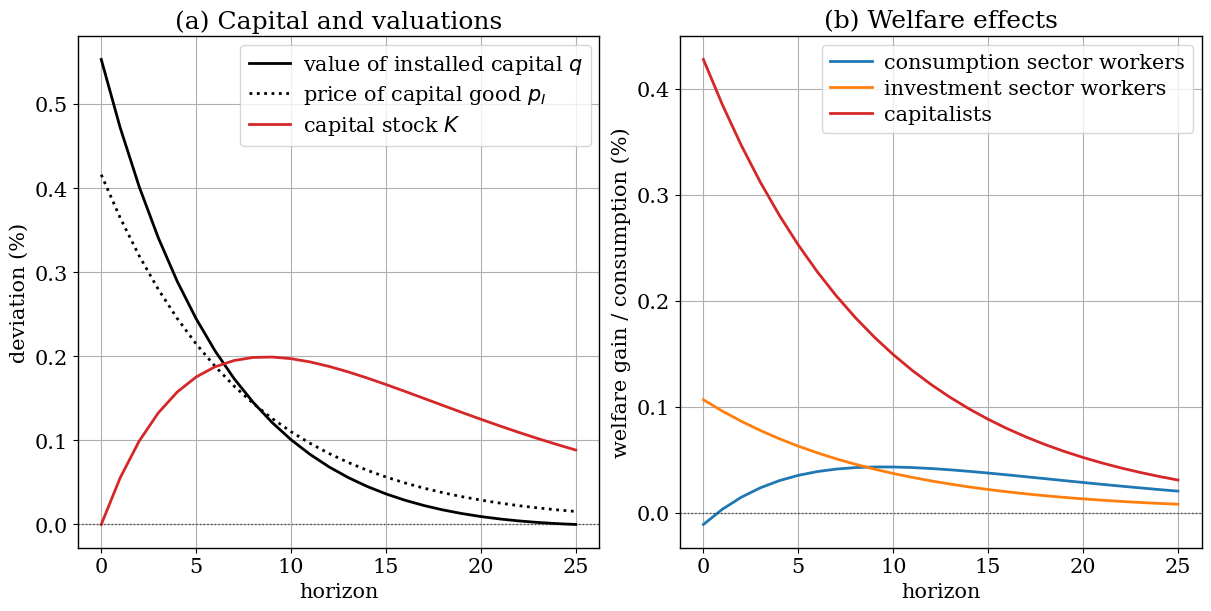

In [44]:
# run
m = CapIncModel()
fig, axes, ss, sim = plot_figure5(m, T=25, tau_ss=0.0, size=0.01, decay=0.10)
plt.show()

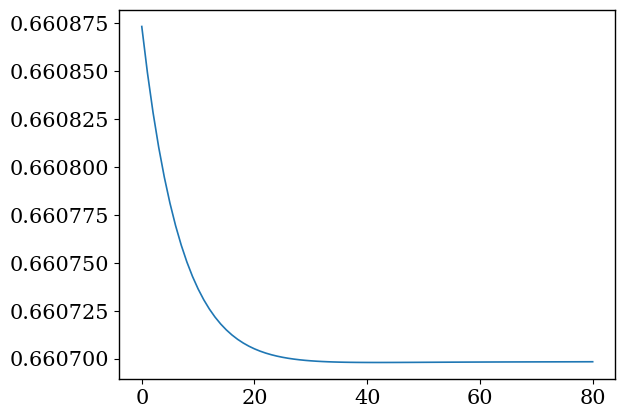

In [42]:
def compute_labor_share_from_sim(m, sim):
    # 1) value added in consumption units
    C  = np.asarray(sim["C"], float)
    I  = np.asarray(sim["I"], float)
    pI = np.asarray(sim["pI"], float)
    Y  = C + pI * I

    # 2) value weights of sectors
    wI = (pI * I) / Y
    wC = C / Y

    # 3) aggregate labor share (competitive Cobb–Douglas within each sector)
    LS = (1 - m.alphaK) * wC + (1 - m.betaK) * wI
    return {"Y": Y, "wC": wC, "wI": wI, "LS": LS}

# --- run a tax shock and compute LS ---
m = CapIncModel()
ss = m.solve_steady_state()

T, size, decay = 80, 0.01, 0.1  # horizon, dlog(1-τ) size, decay
net_t, tau_t, dlog_net = m.net_tax_path(T=T, tau_ss=0.0, size=size, decay=decay)

sim = m.solve_transition(tau_path=tau_t)

ls = compute_labor_share_from_sim(m, sim)

plt.plot(ls['LS'])

so a lower income share increases aggregate growth? will the opposite shock reduce the growth/aggregate wealth in the economy?

consider deleting the $q_T=q_{ss}$